# AICE Associate 스타일 모의 문항 ① 카시트 판매량 예측

> 공식 **AICE Associate 샘플 문항(14문항)** 의 구성과 요구사항 형식을 참고해 **새로 만든 연습 문제**입니다.
> 실제 시험 문항·데이터와는 다릅니다.

### 문제 상황
카시트를 판매하는 매장 체인의 **매장 정보**와 **판매 실적** 데이터가 두 파일로 나뉘어 있습니다.
두 데이터를 합쳐 전처리한 뒤, 머신러닝과 딥러닝으로 **매장별 판매량(Sales, 천 개)** 을 예측합니다.

| 파일 | 주요 열 |
|---|---|
| `carseats_store.csv` | StoreID, Region(지역), CompPrice(경쟁사 가격), Income(지역 소득), Advertising(광고비), Population(인구), Price(판매가), ShelveLoc(진열 위치), Age(평균 연령), Education, Urban, US, Open_Date(개점일) |
| `carseats_sales.csv` | StoreID, **Sales(판매량, 예측 대상)**, Survey_Date(조사일) |

### 진행 방법
- `# 여기에 답안코드를 작성하세요` 칸에 코드를 작성하고 실행한 뒤, 아래 `check(번호)` 셀로 채점합니다.
- 막히면 `hint(번호)`, 마지막에 `score()` 로 점수를 확인합니다. (14문항, 80점 이상 합격 기준)
- **변수명은 문제에서 지정한 이름을 그대로** 사용하세요. 문항은 앞 문항의 결과를 이어서 사용합니다.
- 같은 폴더에 `aice_grader_carseats.py`, `carseats_store.csv`, `carseats_sales.csv` 가 있어야 합니다.
- 필요 라이브러리: pandas, scikit-learn, seaborn, matplotlib, tensorflow


In [1]:
# [준비] 채점 모듈 불러오기 - 먼저 실행하세요
%matplotlib inline
from aice_grader_carseats import check, hint, score, Q4_CHOICES

### 1. scikit-learn 패키지를 사용하기 위해 import 하려고 합니다.
- `sklearn` 을 **sk** 로 import 하세요.

In [2]:
# 여기에 답안코드를 작성하세요
import sklearn as sk

In [3]:
check(1)

✅ [문항 1] scikit-learn import — 정답!


### 2. Pandas 는 데이터 분석을 위해 널리 사용되는 파이썬 라이브러리입니다.
- Pandas 를 사용할 수 있도록 **pd** 라는 별칭으로 import 하세요.

In [4]:
# 여기에 답안코드를 작성하세요
import pandas as pd

In [5]:
check(2)

✅ [문항 2] pandas import — 정답!


### 3. 두 개의 데이터 파일을 읽어 하나로 합치려고 합니다.
- `carseats_store.csv` 를 읽어 **df_store** 에 저장하세요.
- `carseats_sales.csv` 를 읽어 **df_sales** 에 저장하세요.
- 두 데이터프레임을 **'StoreID'** 를 기준으로 **inner join** 하여 **df** 에 저장하세요.

In [12]:
# 여기에 답안코드를 작성하세요
df_store = pd.read_csv("carseats_store.csv")
df_sales = pd.read_csv("carseats_sales.csv")

df = df_store.merge(df_sales, on="StoreID", how="inner")

In [14]:
df.head()

,StoreID,Region,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Open_Date,Sales,Survey_Date
0,S001,North,138,73.0,11,276,120,Bad,42.0,17,Yes,Yes,2021-04-02,9.50,2024-06-14
1,S002,East,111,48.0,16,260,83,Good,65.0,10,Yes,Yes,2022-08-01,11.22,2024-09-21
2,S003,South,113,35.0,10,269,80,Medium,59.0,12,Yes,Yes,2019-08-16,10.06,2024-10-17
3,S004,South,117,100.0,4,466,97,Medium,55.0,14,Yes,Yes,2022-11-22,7.40,2024-05-06
4,S005,South,141,64.0,3,340,128,Bad,38.0,13,Yes,No,2015-09-04,4.15,2024-04-13


In [13]:
check(3)

✅ [문항 3] 파일 읽기·병합 — 정답!


### 4. Region(지역) 컬럼의 분포를 확인하려고 합니다.
- **seaborn** 을 **sns** 로 import 하고, `countplot` 으로 df 의 **Region** 분포를 그려 결과를 **ax4** 에 저장하세요.
- 그래프를 보고 아래 보기 중 **옳지 않은** 설명의 번호를 **답안04** 에 저장하세요.
- 그다음, Region 값이 **'-'** 인 행을 삭제하여 다시 **df** 에 저장하세요.

1. North 지역 매장 수가 가장 많다.
2. 지역 정보가 '-' 로 기재된 매장이 있다.
3. East 지역 매장 수가 West 지역 매장 수보다 많다.
4. North 와 South 의 매장 수 차이는 10개 미만이다.


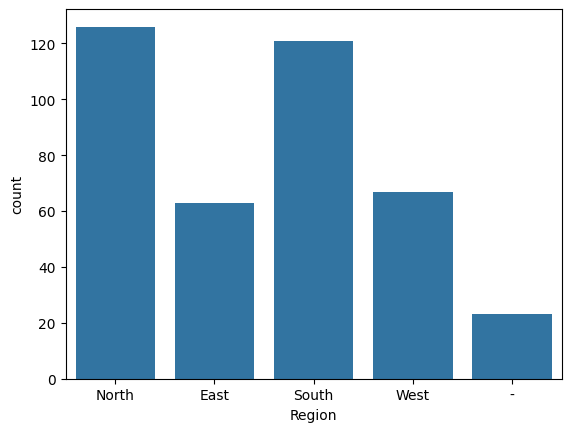

In [16]:
for c in Q4_CHOICES: print(c)

# 여기에 답안코드를 작성하세요
import seaborn as sns

ax4 = sns.countplot(data=df, x='Region')

답안04 = 3

df = df.drop(df[df["Region"] == '-'].index)


In [19]:
check(4)

✅ [문항 4] 지역 분포 시각화·'-' 행 삭제 — 정답!


### 5. 판매가(Price)와 판매량(Sales)의 관계를 확인하려고 합니다.
- seaborn 의 `jointplot` 을 사용하여 **x축은 Price, y축은 Sales** 인 그래프를 그리고, 결과를 **g5** 에 저장하세요.

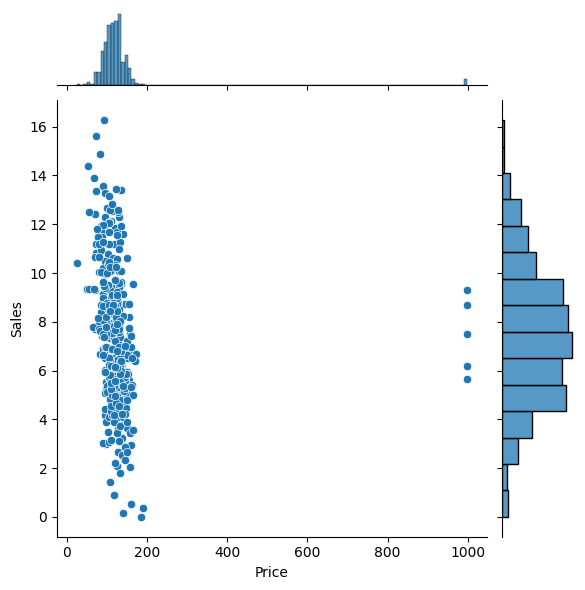

In [21]:
# 여기에 답안코드를 작성하세요
g5 = sns.jointplot(data=df, x="Price", y="Sales")

In [22]:
check(5)

✅ [문항 5] 가격-판매량 jointplot — 정답!


### 6. 문항 5의 그래프에서 가격이 비정상적으로 높은 이상치가 확인됩니다.
- df 에서 **Price 가 300 이상**인 행을 삭제하세요.
- 분석에 필요 없는 **'StoreID'** 컬럼을 삭제하세요.
- 결과를 **df_temp** 에 저장하세요.

In [28]:
# 여기에 답안코드를 작성하세요
df = df.drop(df[df["Price"] >= 300].index)
df_temp = df.drop("StoreID", axis=1)

In [29]:
check(6)

✅ [문항 6] 이상치 삭제·열 삭제 — 정답!


### 7. 결측치를 처리하려고 합니다.
- df_temp 의 **전체 결측치 개수**(숫자 하나)를 **답안07** 에 저장하세요.
- 결측치가 있는 행을 삭제하여 **df_na** 에 저장하세요.

In [47]:
# 여기에 답안코드를 작성하세요
답안07 = df_temp.isnull().sum().sum()

df_na = df_temp.dropna()

In [48]:
check(7)

✅ [문항 7] 결측치 확인·삭제 — 정답!


### 8. 분석에 불필요한 날짜 컬럼을 삭제하려고 합니다.
- df_na 에서 **'Open_Date', 'Survey_Date'** 컬럼을 삭제하여 **df_del** 에 저장하세요.

In [49]:
# 여기에 답안코드를 작성하세요
df_del = df_na.drop(["Open_Date", "Survey_Date"], axis=1)

In [50]:
check(8)

✅ [문항 8] 불필요한 열 삭제 — 정답!


### 9. 모델링을 위해 범주형 데이터를 수치로 변환하려고 합니다.
- df_del 의 **object 타입 컬럼 전체**를 대상으로 pandas 의 `get_dummies` 를 사용해 원-핫 인코딩하세요.
- 결과를 **df_preset** 에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요


In [ ]:
check(9)

### 10. 훈련과 검증 데이터를 나누고 스케일링하려고 합니다.
- 대상 데이터프레임: df_preset / 예측 대상(y): **'Sales'** / 나머지 컬럼은 X
- train : validation = **80 : 20**, **random_state = 42**
- 결과 변수: **X_train, X_valid, y_train, y_valid**
- **RobustScaler** 를 사용해 X_train 은 `fit_transform`, X_valid 는 `transform` 한 결과를 **각각 X_train, X_valid 에 다시 저장**하세요.

In [ ]:
# 여기에 답안코드를 작성하세요


In [ ]:
check(10)

### 11. 판매량을 예측하는 머신러닝 모델을 만들려고 합니다.
- **DecisionTreeRegressor** 를 **dt** 에, **RandomForestRegressor** 를 **rf** 에 저장하세요.
- 두 모델 모두 하이퍼파라미터: **max_depth=5, min_samples_split=3, random_state=120**
- 두 모델을 X_train, y_train 으로 학습하세요.

In [ ]:
# 여기에 답안코드를 작성하세요


In [ ]:
check(11)

### 12. 두 모델의 성능을 평가하려고 합니다.
- 검증 데이터(X_valid, y_valid)로 **MAE(Mean Absolute Error)** 를 계산하여 **dt_mae, rf_mae** 에 저장하세요.
- 성능이 더 좋은 모델을 **'dt'** 또는 **'rf'** 문자열로 **답안12** 에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요


In [ ]:
check(12)

### 13. 판매량을 예측하는 딥러닝 모델을 만들려고 합니다.
- Tensorflow 의 **Sequential** 모델로 만들고 **model** 에 저장하세요.
- 히든 레이어(hidden layer) **2개 이상**, **Dropout 비율 0.2** 레이어 1개 이상
- 출력층은 값 1개를 예측하는 Dense 층
- **loss='mse', metrics=['mse']** 로 compile 하세요.
- **epochs=30, batch_size=16** 으로 학습하고, 검증 데이터로 **X_valid, y_valid** 를 사용하세요.
- 학습 결과(`fit` 의 반환값)를 **history** 에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요


In [ ]:
check(13)

### 14. 딥러닝 모델의 학습 과정을 시각화하려고 합니다.
- history 의 **mse** 와 **val_mse** 를 한 그래프에 그리세요. (x축: epoch)
- 범례 이름은 각각 **'mse', 'val_mse'** 로 지정하세요.
- 그래프를 그린 셀 끝에서 `plt.show()` **이전에** **ax14 = plt.gca()** 로 축을 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요


In [ ]:
check(14)

## 최종 점수

In [ ]:
score()